## TASK 1. PROJECT OVERVIEW & KEY LEARNING OBJECTIVES

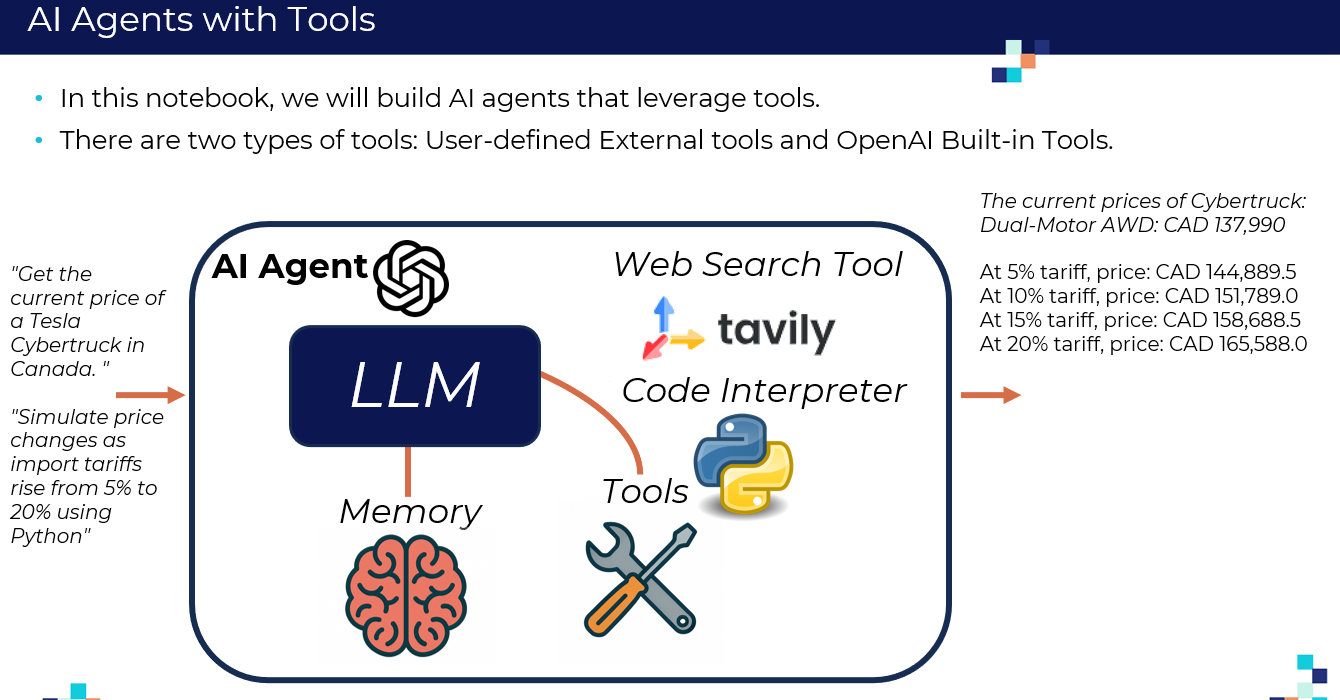

## TASK 2. SETUP OPENAI AND TAVILY API KEYS

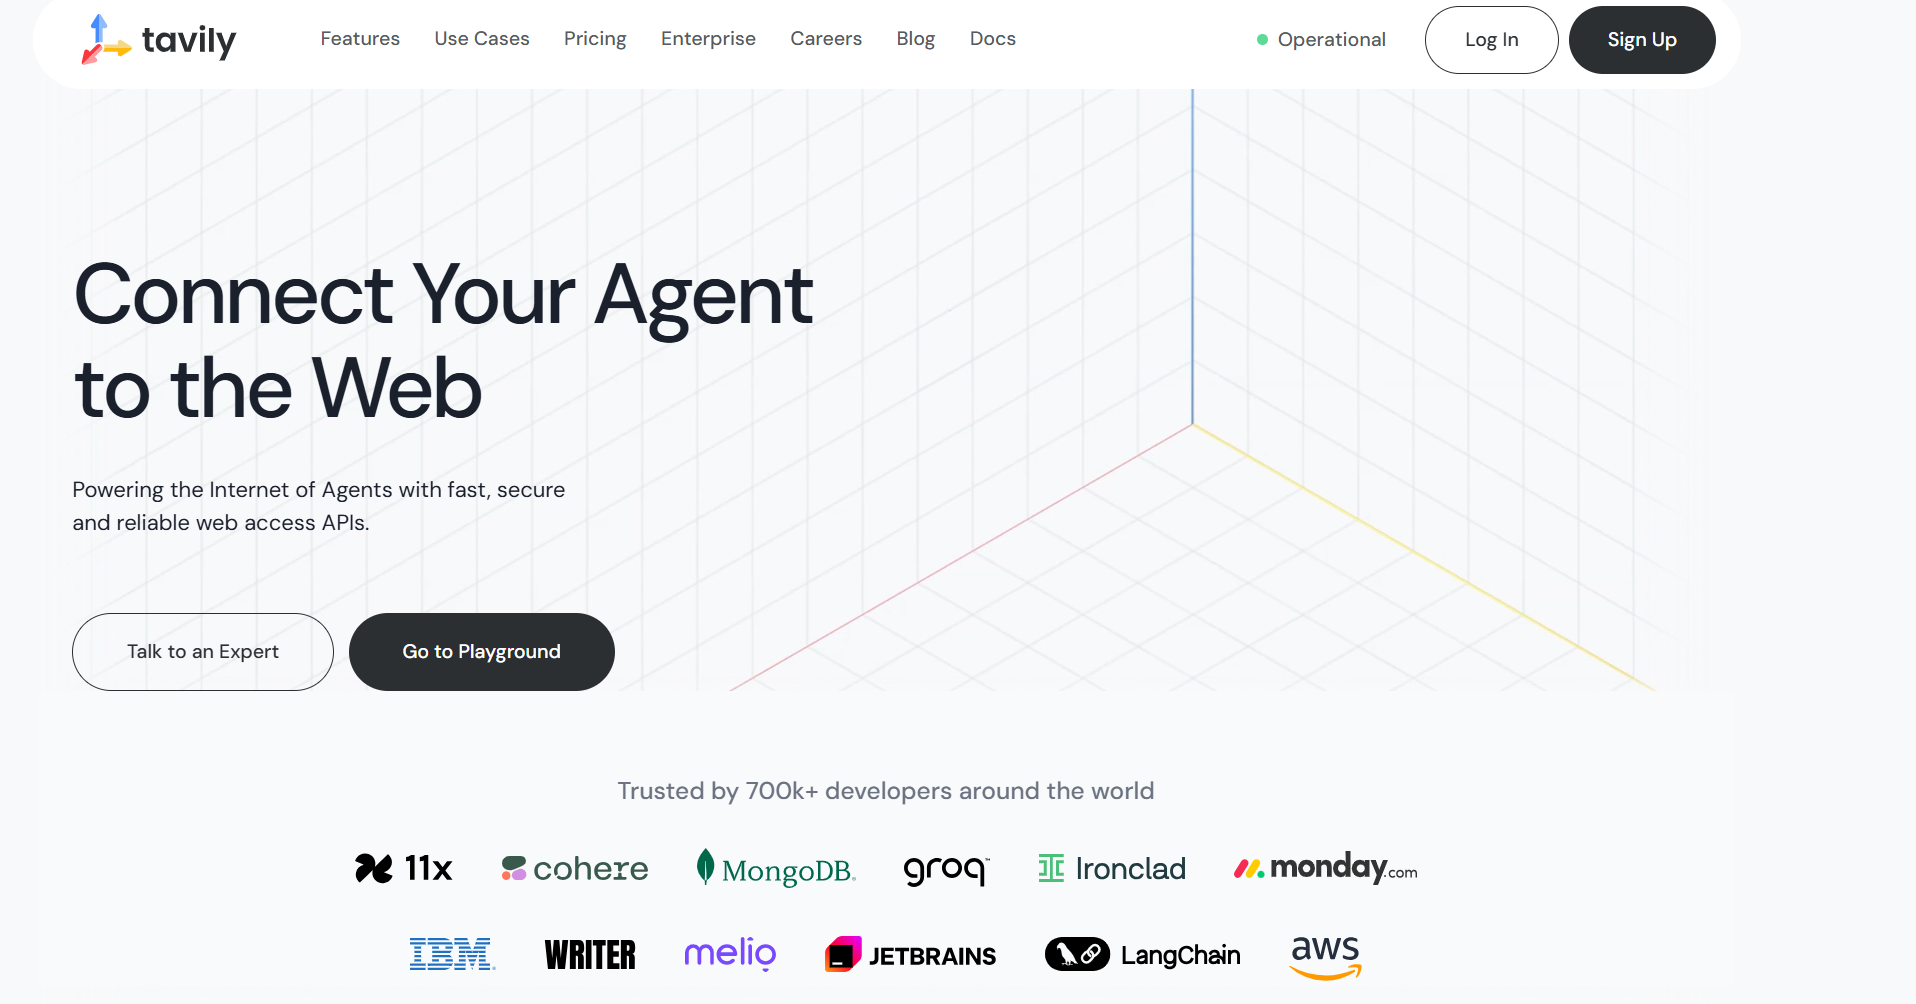

- Tavily is a platform that gives AI agents reliable, structured web access via an easy API, streamlining search workflows.
- Link: https://tavily.com/.
- Action:
    - Sign up for Tavily Self-Service API if you haven't already.
    - Create a .env file in the same directory as this notebook (if you don't have one).
    - Add your keys to the .env file like this:
      - **OPENAI_API_KEY=sk-YourSecretOpenAIKey...**
      - **TAVILY_API_KEY=tvly-YourSecretTavilyKey...**


In [3]:
!pip install -q openai-agents==0.2.2 python-dotenv requests

In [1]:
import os
import requests
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

print("✅ Keys loaded:")
print(f"OpenAI API Key: {openai_api_key[:5]}***")
print(f"Tavily API Key: {tavily_api_key[:5]}***")

openai_client = OpenAI(api_key=openai_api_key)


✅ Keys loaded:
OpenAI API Key: sk-pr***
Tavily API Key: tvly-***


In [2]:
def print_markdown(text: str):
    display(Markdown(text))

## TASK 3: DEFINE TAVILY SEARCH FUNCTION & CREATE A TOOL

In [4]:
import json  # Import the json module for handling JSON data
from typing_extensions import TypedDict  # Import TypedDict for type hinting
from agents import function_tool

In [5]:
# Define a TypedDict for the expected parameters for the Tavily search function
# A TypedDict is like a blueprint for a dictionary in Python
# It tells Python exactly what keys the dictionary should have and what type of values go with each key.

class TavilySearchParams(TypedDict):
    query: str         # The search query string
    max_results: int   # The maximum number of results to return

In [6]:
# Let's define a function that searches the web using the Tavily API and gives back a short summary of the top results.
# Decorate the function as a FunctionTool for OpenAI Agents SDK
@function_tool
def tavily_search(params: TavilySearchParams) -> str:
    """
    Calls the Tavily API and returns a string summary of top search results.

    Args:
        params (TavilySearchParams): Dictionary with 'query' (str) and 'max_results' (int).

    Returns:
        str: A formatted string summarizing the top search results, or an error message.
    """

    # The web address (endpoint) for sending search requests to Tavily ( Tavily API endpoint)
    url = "https://api.tavily.com/search" 

    # Tell the API that we’re sending JSON data
    headers = {"Content-Type": "application/json"}  

    # What we’re sending to the API:
    # Our secret API key (so Tavily knows it's us)
    # The search text (query)
    # How many results we want (defaults to 2 if not given)
    payload = {
        "api_key": tavily_api_key,  # Use the Tavily API key from environment
        "query": params["query"],   # The search query from params
        "max_results": params.get("max_results", 2),  # Use max_results from params, default to 2 if not provided
    }

    # Send the search request to Tavily (POST means we’re sending data)
    response = requests.post(url, json = payload, headers = headers) 

    # Check if the search worked (200 = OK)
    if response.status_code == 200:  # If the request was successful
        results = response.json().get("results", [])  # Extract the 'results' list from the response JSON
        
        # Build a summary string with each result's title and content, numbered
        summary = "\n".join([f"{i+1}. {r['title']}: {r['content']}" for i, r in enumerate(results)])
        return summary if summary else "No relevant results found."  # Return summary or fallback message
    else:
        return f"Tavily API error: {response.status_code}"  # Return error message with status code if request failed


**PRACTICE OPPORTUNITY:**
- **Modify the tavily_search function so that it returns only the titles of the search results, without including the content.**
- **Increase the number of results returned from 2 to 3 by updating the max_results parameter in the function.**

## TASK 4: BUILD AND RUN AN AI AGENT WITH SEARCH TOOL 

In [7]:
# Let's add memory to our agent
from agents import SQLiteSession
session = SQLiteSession("live_researcher_practice")

In [8]:
from agents import Agent

live_researcher_agent = Agent(name = "Live Market Researcher",
                             instructions = """
CONTEXT:
You are a world-class market research assistant with access to real-time web search via the tavily_search tool.

INSTRUCTION:
- Analyze the user's question and determine if recent or real-time information is needed.
- If the question involves recent events, news, or product info, always call tavily_search.
- Summarize search results clearly and concisely, do not copy-paste.
- Always start your answer with: "🔍 According to a web search …"

INPUT:
You will receive a conversation history and the latest user question. Use the full context to inform your response.

OUTPUT:
Provide a clear, well-structured answer that references the search results when appropriate. If you use tavily_search, integrate the findings into your summary.
""",
    model = "gpt-4.1-mini",
    tools = [tavily_search])

print("✅ Agent created with Tavily tool.")

✅ Agent created with Tavily tool.


In [9]:
from agents import Runner

# First question
q1 = "What are people saying about the new GPT-5 Model?"

print_markdown(f"**User:** {q1}")

run1 = await Runner.run(
    starting_agent = live_researcher_agent,
    input = q1,
    session = session,
)

print_markdown(f"### 🤖 Agent’s Answer\n{run1.final_output}")


**User:** What are people saying about the new GPT-5 Model?

### 🤖 Agent’s Answer
🔍 According to a web search, people are saying the new GPT-5 model by OpenAI brings several notable advancements and characteristics:

1. GPT-5 introduces four adjustable levels of reasoning (minimal, low, medium, high) allowing users to control the depth of thinking and resource use. This makes it powerful for deeper analysis but slightly slower than GPT-4.1, which is optimized for speed and real-time tasks like chat and customer support.

2. GPT-5 is available in three variants—regular, mini, and nano—and integrates multimodal inputs, real-time streaming, and advanced tool support for dynamic user experiences.

3. The model includes improved safety measures to refuse unsafe requests and demonstrates better performance in reasoning and coding tasks, seen as key for future development (like GPT-6).

4. Some users note it's an overall improvement in price-performance balance, though a few find the upgrade somewhat underwhelming compared to other models like Anthropic's Claude 4.

5. GPT-5 simplifies user experience by internally choosing the best model variant based on task complexity, resulting in strong benchmark results and practical usefulness.

Overall, GPT-5 is viewed as a more capable, reasoned, and versatile AI model, though with trade-offs in speed for more intensive reasoning tasks and some limitations in creative writing and advanced AGI testing.

- **Note: You can monitor all tools used by the Agent through traces, available in the OpenAI platform when you log in to your account.**
- **Link: https://platform.openai.com/logs/**

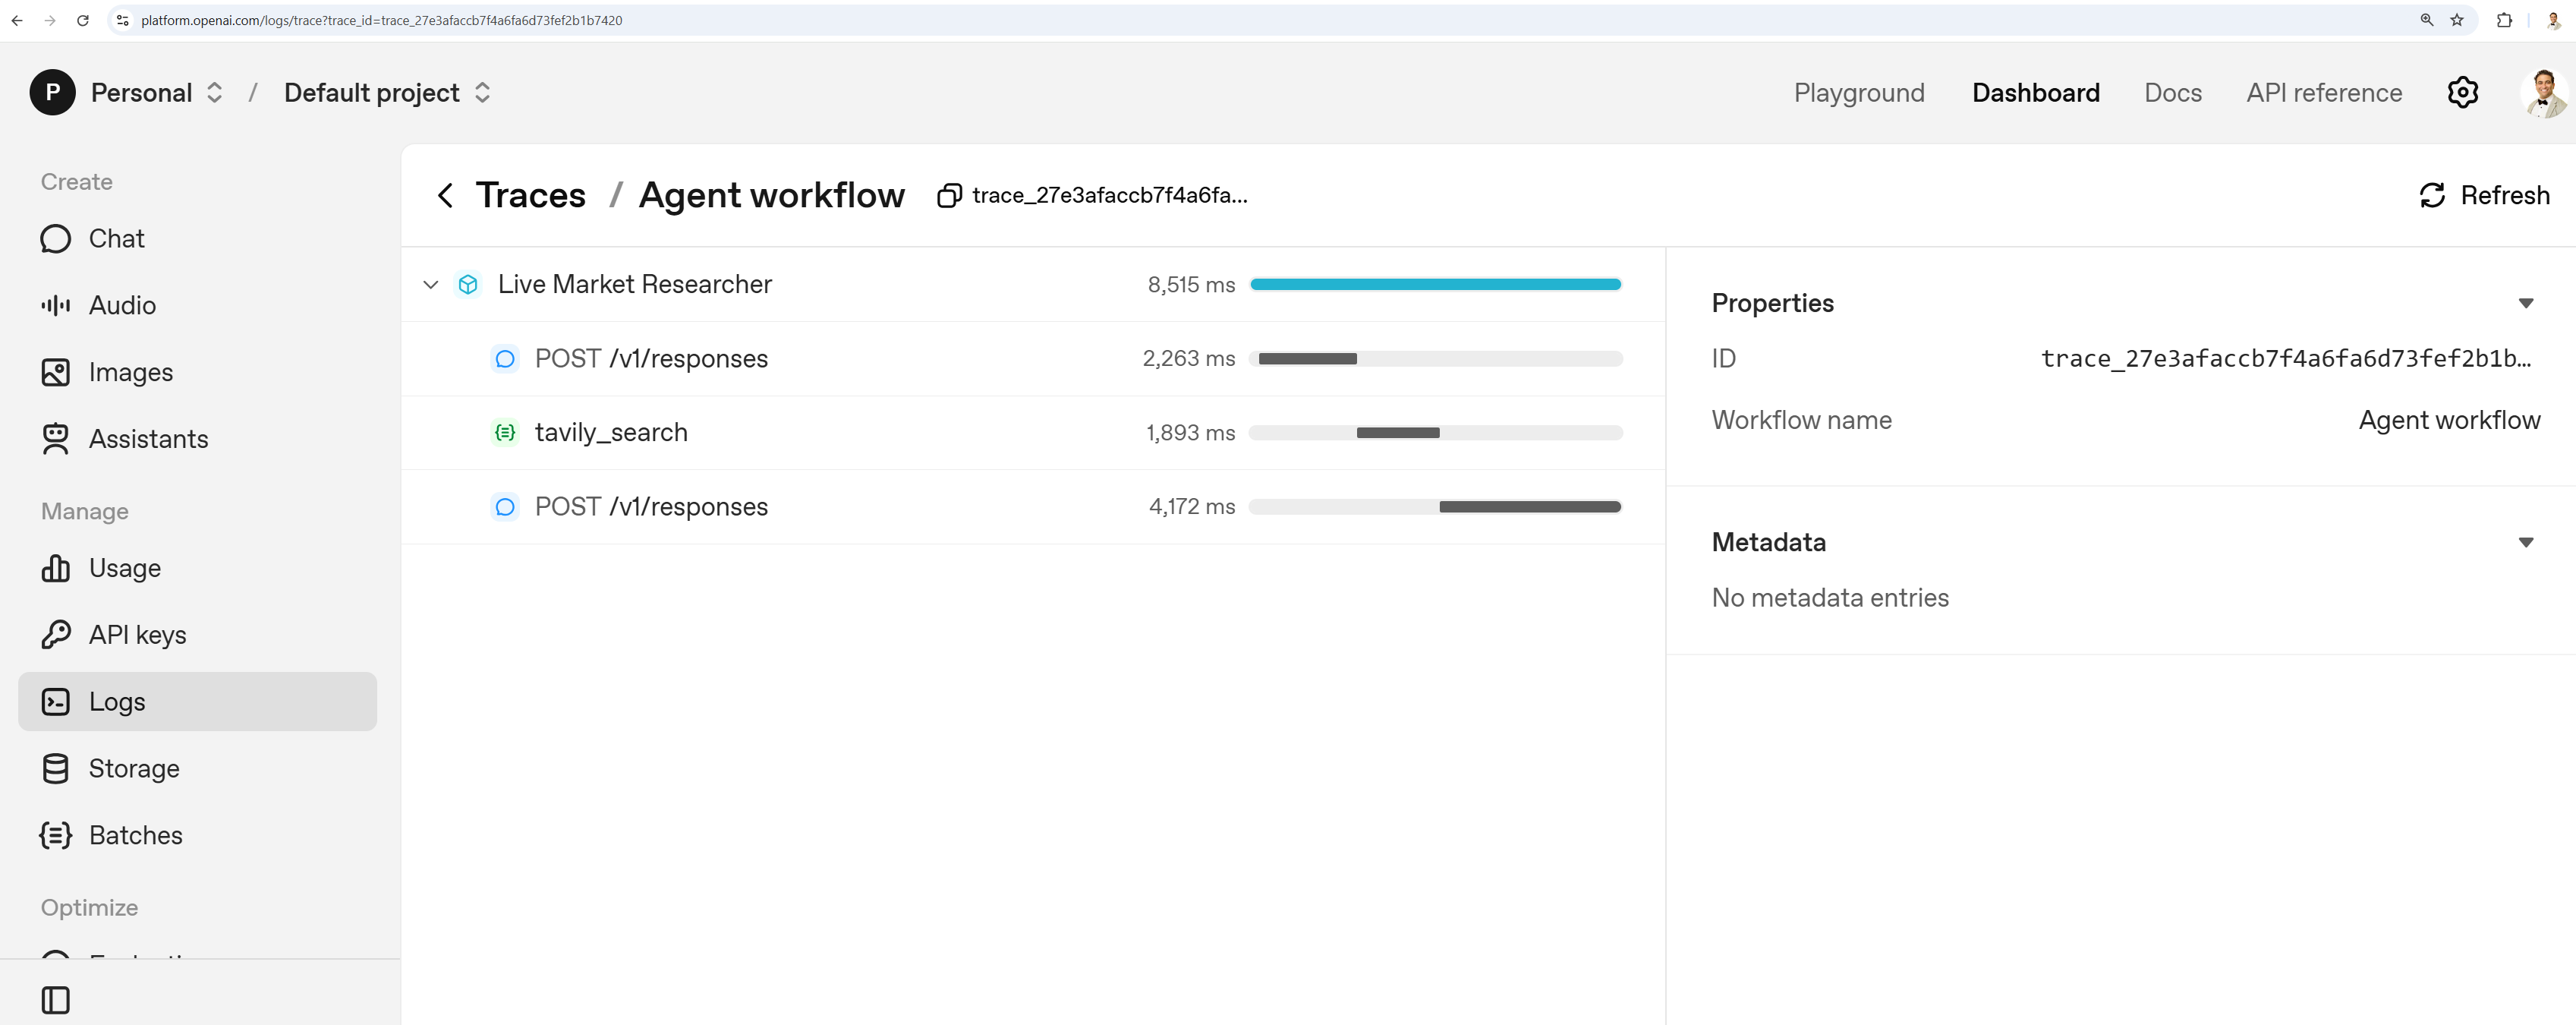

**PRACTICE OPPORTUNITY:**  
- **Use the `live_researcher_agent` AI agent to find and summarize the key features of your favorite vehicle, it can be electric or conventional.**  
    - **Example:** *"What do reviewers say about the new Cybertruck?"*  
    - **Then test its memory and search ability with a follow-up:** *"Summarize the main features."*  

## TASK 5. LEVERAGE EXISTING OPENAI BUILT-IN TOOLS

- Instead of creating a tool, you can leverage existing tools available in OpenAI Agents SDK: https://openai.github.io/openai-agents-python/ref/tool/
    - **WebSearchTool:** Let your agent do a real‑time web search 
    - **FileSearchTool:** Search your vector stores for content retrieval 
    - **ComputerTool:** Have the agent take actions on your system like clicking or typing 
    - **CodeInterpreterTool, ImageGenerationTool, HostedMCPTool:** Extra built‑ins for code, visuals, MCP connections all ready to go

In [10]:
import json  # Import the json module for handling JSON data
from typing_extensions import TypedDict, Any  # Import TypedDict for type hinting, Any for general typing

# from agents import FunctionTool, function_tool, RunContextWrapper, CodeInterpreterTool # Import agent tool decorators and helpers
from agents import FunctionTool, function_tool, CodeInterpreterTool # Import agent tool decorators and helpers

# Use the hosted CodeInterpreterTool to provide a safe, sandboxed Python execution environment for the agent.
# This tool allows the agent to run Python code in a secure container, which is isolated from the main system.
# The 'tool_config' specifies that we want an automatic container (per documentation).
code_interpreter = CodeInterpreterTool(
    tool_config = {"type": "code_interpreter", 
                   "container": {"type": "auto"}})

# Print a message to confirm that all tools (get_catalog, run_readonly_sql, code_interpreter) are ready for use.
print("✅ Tool ready: code_interpreter")

✅ Tool ready: code_interpreter


In [11]:
from agents import Agent

analyst_agent = Agent(name = "Analyst Agent",
                      instructions = """
CONTEXT:
You are a world-class market research assistant with access to both real-time web search (via the tavily_search tool) and Python code execution (via the code_interpreter tool).

INSTRUCTION:
- Carefully analyze the user's question to determine whether it requires:
    - Recent or real-time information (use tavily_search),
    - Data analysis, calculations, or code execution (use code_interpreter),
    - Or a combination of both tools.
- Use tavily_search for up-to-date facts, news, or product information.
- Use code_interpreter for tasks involving data analysis, calculations, or code-based reasoning.
- If the task benefits from both tools, use them together and integrate the results.
- Clearly summarize your findings and reasoning. Do not copy-paste search results; always paraphrase.
- When using search, begin your answer with: "🔍 According to a web search …"
- When using code, explain your process and results clearly.

INPUT:
You will receive a conversation history and the latest user question. Use the full context to decide which tool(s) to use and to inform your response.

OUTPUT:
Provide a clear, well-structured answer. Reference search results and/or code outputs as appropriate, and integrate them into your summary.
""",
    model = "gpt-4.1-mini",
    tools = [tavily_search, code_interpreter],
)

print("✅ Agent created with Tavily and Code Interpreter tools.")

✅ Agent created with Tavily and Code Interpreter tools.


In [12]:
session = SQLiteSession("live_researcher")

# New question: Ask the agent to get the current price of a Tesla Cyber Truck in Canada,
# then simulate the price increase if tariffs rise from 5% to 20% in 1% increments,
# and calculate the new prices using Python, providing a summary across all scenarios.

q1 = (
    "Find the current price of a Tesla Cyber Truck in Canada. "
    "Then, simulate how the price would change if import tariffs increased from 5% to 20% in 1% increments. "
    "For each tariff rate, calculate the new price using Python and provide a summary of the results across all scenarios."
)

print_markdown(f"**User:** {q1}")

run1 = await Runner.run(
    starting_agent = analyst_agent,
    input = q1,
    session = session,
)

print_markdown(f"### 🤖 Agent’s Answer\n{run1.final_output}")

**User:** Find the current price of a Tesla Cyber Truck in Canada. Then, simulate how the price would change if import tariffs increased from 5% to 20% in 1% increments. For each tariff rate, calculate the new price using Python and provide a summary of the results across all scenarios.

### 🤖 Agent’s Answer
The current price of a Tesla Cybertruck in Canada is approximately CAD 137,990.

I simulated how the price would change if the import tariffs increased steadily from 5% to 20% in 1% increments. Here are the results:

- At 5% tariff, the price would be CAD 144,889.50
- At 6% tariff, the price would be CAD 146,269.40
- At 7% tariff, the price would be CAD 147,649.30
- At 8% tariff, the price would be CAD 149,029.20
- At 9% tariff, the price would be CAD 150,409.10
- At 10% tariff, the price would be CAD 151,789.00
- At 11% tariff, the price would be CAD 153,168.90
- At 12% tariff, the price would be CAD 154,548.80
- At 13% tariff, the price would be CAD 155,928.70
- At 14% tariff, the price would be CAD 157,308.60
- At 15% tariff, the price would be CAD 158,688.50
- At 16% tariff, the price would be CAD 160,068.40
- At 17% tariff, the price would be CAD 161,448.30
- At 18% tariff, the price would be CAD 162,828.20
- At 19% tariff, the price would be CAD 164,208.10
- At 20% tariff, the price would be CAD 165,588.00

This shows that the price increases linearly with tariff rate increments, with a total increase of about CAD 27,598 if the tariff rises from 5% to 20%. Let me know if you would like this data in a file format or visualized!

# PRACTICE OPPORTUNITY SOLUTIONS

**PRACTICE OPPORTUNITY SOLUTION:**
- **Modify the tavily_search function so that it returns only the titles of the search results, without including the content.**
- **Increase the number of results returned from 2 to 3 by updating the max_results parameter in the function.**

In [ ]:
@function_tool
def tavily_search(params: TavilySearchParams) -> str:
    """
    Calls the Tavily API and returns a string of only the titles
    from the top search results.
    """
    url = "https://api.tavily.com/search"  # Tavily API endpoint
    headers = {"Content-Type": "application/json"}  # Request headers
    payload = {
        "api_key": tavily_api_key,
        "query": params["query"],  # Search query from params
        "max_results": params.get("max_results", 3)  # Default 3 results instead of 2
    }

    response = requests.post(url, json=payload, headers=headers)

    if response.status_code == 200:
        results = response.json().get("results", [])
        
        # Only return numbered titles
        summary = "\n".join([f"{i+1}. {r['title']}" for i, r in enumerate(results)])
        
        return summary if summary else "No relevant results found."
    else:
        return f"Tavily API error: {response.status_code}"


**PRACTICE OPPORTUNITY SOLUTION:**  
- **Use the `live_researcher_agent` AI agent to find and summarize the key features of your favorite vehicle, it can be electric or conventional.**  
    - **Example:** *"What do reviewers say about the new Cybertruck?"*  
    - **Then test its memory and search ability with a follow-up:** *"Summarize the main features."*  

In [ ]:
from agents import Runner

session = SQLiteSession("live_researcher_practice")

prod_memory = []
q1 = "What do reviewers say about the new Tesla Cybertruck?"

print_markdown(f"**User:** {q1}")
run1 = await Runner.run(live_researcher_agent, q1, session = session)
print_markdown(f"**Answer:** {run1.final_output}")

In [ ]:
q2 = "Summarize the main features in one paragraph"
print_markdown(f"**User:** {q2}")
run2 = await Runner.run(live_researcher_agent, q2, session = session)
print_markdown(f"**Answer:** {run2.final_output}")
